In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix, auc, roc_curve, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/UUI/ProjektUmjetna

/content/drive/MyDrive/Colab Notebooks/UUI/ProjektUmjetna


In [4]:
hotel_df = pd.read_csv('hotel_bookings.csv')

In [5]:
hotel_df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
hotel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
hotel_df.shape

(119390, 32)

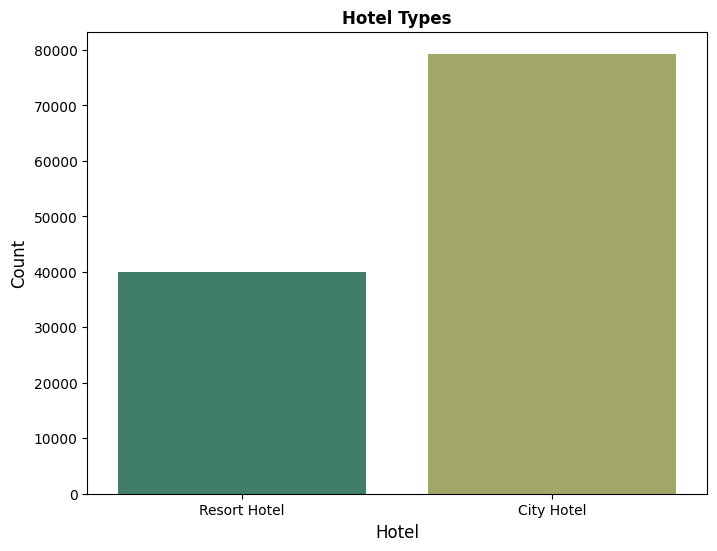

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(x='hotel', data = hotel_df, hue = 'hotel', palette='gist_earth', legend = False)
plt.title('Hotel Types', weight='bold')
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

Text(0, 0.5, 'Count')

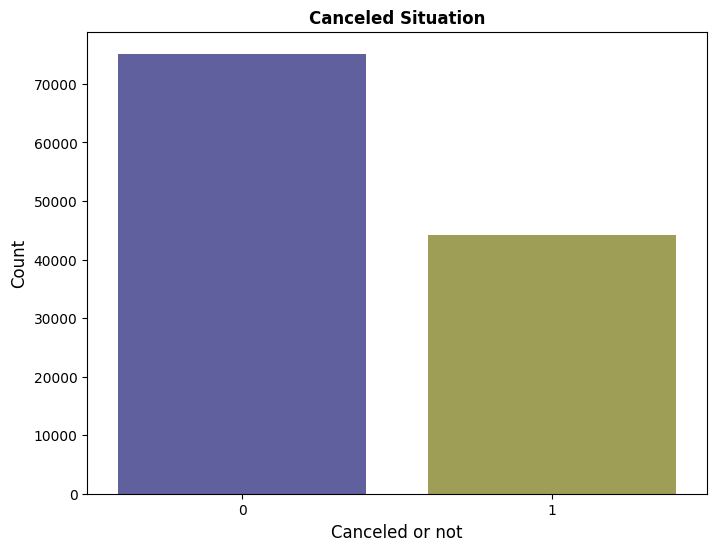

In [9]:
plt.figure(figsize=(8,6))
sns.countplot(x='is_canceled', data= hotel_df, hue='is_canceled', palette='gist_stern', legend=False)
plt.title('Canceled Situation', weight='bold')
plt.xlabel('Canceled or not', fontsize=12)
plt.ylabel('Count', fontsize=12)

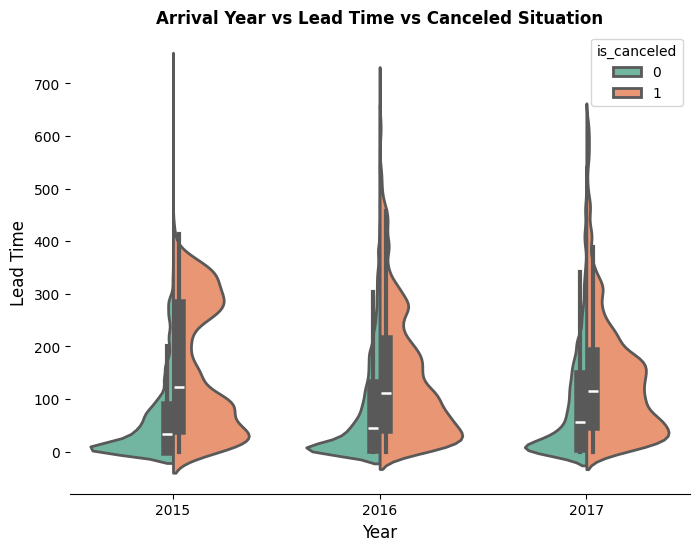

In [10]:
plt.figure(figsize=(8,6))
sns.violinplot(x='arrival_date_year', y ='lead_time', hue="is_canceled", data=hotel_df, palette="Set2", bw_adjust=1,
               cut=2, linewidth=2, inner= 'box', split = True)
sns.despine(left=True)
plt.title('Arrival Year vs Lead Time vs Canceled Situation', weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Lead Time', fontsize=12)
plt.show()

In [11]:
#`arrival_date_month` names converted to the numbers

hotel_df['arrival_date_month'] = hotel_df['arrival_date_month'].replace({'January' : '1',
        'February' : '2',
        'March' : '3',
        'April' : '4',
        'May' : '5',
        'June' : '6',
        'July' : '7',
        'August' : '8',
        'September' : '9',
        'October' : '10',
        'November' : '11',
        'December' : '12'
})

In [12]:
print(hotel_df.dtypes)


hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

Text(0, 0.5, 'Count')

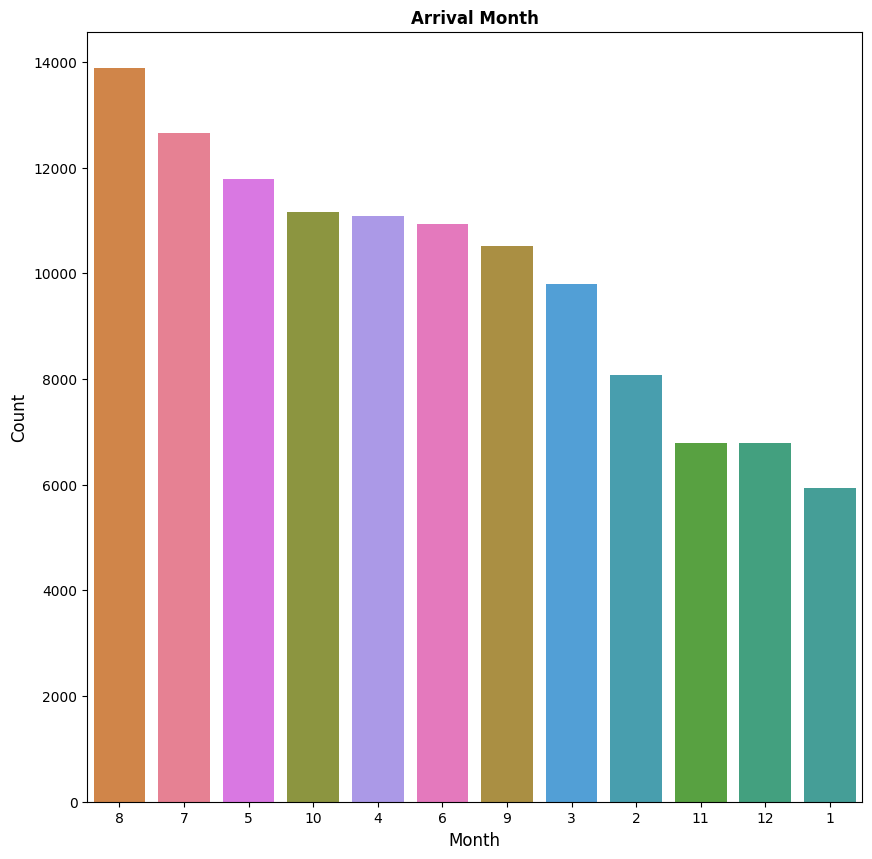

In [13]:
plt.figure(figsize=(10,10))
sns.countplot(x='arrival_date_month', data = hotel_df,
              order=pd.Series(hotel_df['arrival_date_month']).value_counts().index, hue='arrival_date_month',legend=False)
plt.title('Arrival Month', weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Count', fontsize=12)

In [14]:
# Table of `stay_in_weekend` and `stay_in_week_nights` features

pd.crosstab(index = hotel_df['stays_in_week_nights'],columns=hotel_df['stays_in_weekend_nights'], margins=True, margins_name = 'Total').iloc[:10]

stays_in_weekend_nights,0,1,2,3,4,5,6,7,8,9,10,12,13,14,16,18,19,Total
stays_in_week_nights,,,,,,,,,,,,,,,,,,
0,715,4569,2361,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7645
1,16451,7326,6533,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30310
2,17956,8979,6749,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33684
3,11564,6152,4542,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22258
4,4482,2412,2669,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9563
5,830,1188,8655,310,94,0,0,0,0,0,0,0,0,0,0,0,0,11077
6,0,0,851,301,347,0,0,0,0,0,0,0,0,0,0,0,0,1499
7,0,0,446,399,184,0,0,0,0,0,0,0,0,0,0,0,0,1029
8,0,0,393,131,132,0,0,0,0,0,0,0,0,0,0,0,0,656


In [15]:
def week_function(df):
    conditions = [
        (df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] > 0),
        (df['stays_in_weekend_nights'] > 0) & (df['stays_in_week_nights'] == 0),
        (df['stays_in_weekend_nights'] > 0) & (df['stays_in_week_nights'] > 0),
        (df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)
    ]

    choices = [
        'stay_just_weekend',
        'stay_just_weekday',
        'stay_both_weekday_and_weekend',
        'undefined_data'
    ]

    df['weekend_or_weekday'] = np.select(conditions, choices, default='undefined_data')

# Primjena funkcije na DataFrame
week_function(hotel_df)

Text(0, 0.5, 'Count')

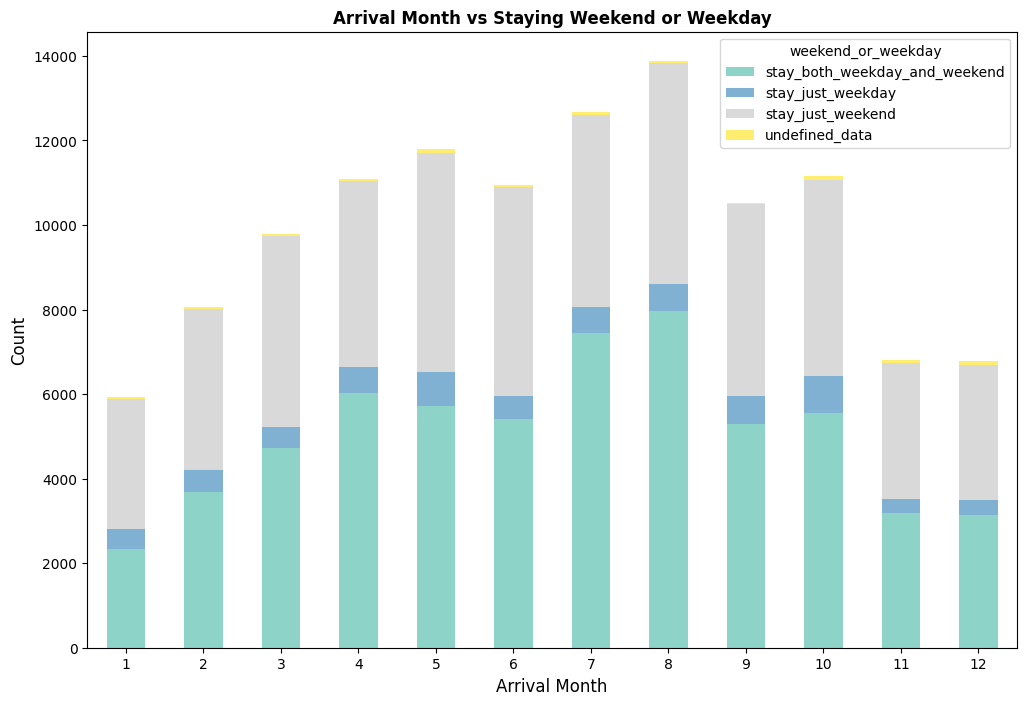

In [16]:
#`arrival_date_month` vs `weekend_or_weekday` graph

hotel_df['arrival_date_month']= hotel_df['arrival_date_month'].astype('int64')
group_data = hotel_df.groupby([ 'arrival_date_month','weekend_or_weekday']).size().unstack(fill_value=0)

group_data.sort_values('arrival_date_month', ascending = True).plot(kind='bar',stacked=True, cmap='Set3',figsize=(12,8))
plt.title('Arrival Month vs Staying Weekend or Weekday', weight='bold')
plt.xlabel('Arrival Month', fontsize=12)
plt.xticks(rotation=360)
plt.ylabel('Count', fontsize=12)

In [17]:
# Create new feature:`all_children` with merge children and baby features

hotel_df['all_children'] = hotel_df['children'] + hotel_df['babies']
pd.crosstab(hotel_df['adults'], hotel_df['all_children'], margins=True, margins_name = 'Total')

all_children,0.0,1.0,2.0,3.0,9.0,10.0,Total
adults,,,,,,,
0,180,4,205,14,0,0,403
1,22577,286,157,6,1,0,23027
2,81557,4658,3369,91,0,2,89677
3,5665,495,41,0,0,0,6201
4,59,3,0,0,0,0,62
5,2,0,0,0,0,0,2
6,1,0,0,0,0,0,1
10,1,0,0,0,0,0,1
20,2,0,0,0,0,0,2


Ovdje smo kombinirali broj djece i beba za svakog gosta i stvaramo novi stupac all_children.


In [18]:
# Groupby `Meal` and `Hotel` features

group_meal_data = hotel_df.groupby(['hotel','meal']).size().unstack(fill_value=0).transform(lambda x: x/x.sum())
group_meal_data.applymap('{:.2f}'.format)

<ipython-input-18-aef263aeb735>:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  group_meal_data.applymap('{:.2f}'.format)


meal,BB,FB,HB,SC,Undefined
hotel,,,,,
City Hotel,0.67,0.06,0.44,0.99,0.00
Resort Hotel,0.33,0.94,0.56,0.01,1.00


hotel_df.groupby(['hotel', 'meal']): Ovdje grupiramo podatke prema kombinaciji dvaju stupaca: hotel i meal. To znači da se podaci grupiraju prema hotelu i vrsti obroka

.size(): Funkcija size() se koristi za brojanje broja zapisa u svakoj grupi. Na primjer, koliko puta se određeni hotel i obrok pojavljuju u podacima.

.unstack(fill_value=0): Metoda unstack() pretvara grupirane podatke u format tablice (odnosno, pivot-tablicu). Svaka kombinacija hotel i meal postat će zaseban stupac, a broj zapisa (rezervacija) bit će vrijednost unutar tih stupaca. Ako neka kombinacija ne postoji, bit će popunjena sa 0 (zahvaljujući fill_value=0).

BB = Bed and Breakfast (samo noćenje s doručkom)
HB = Half board (polupansion)
SC = Self catering (samo smještaj bez obroka)

**DRŽAVE**

Text(0, 0.5, 'Count')

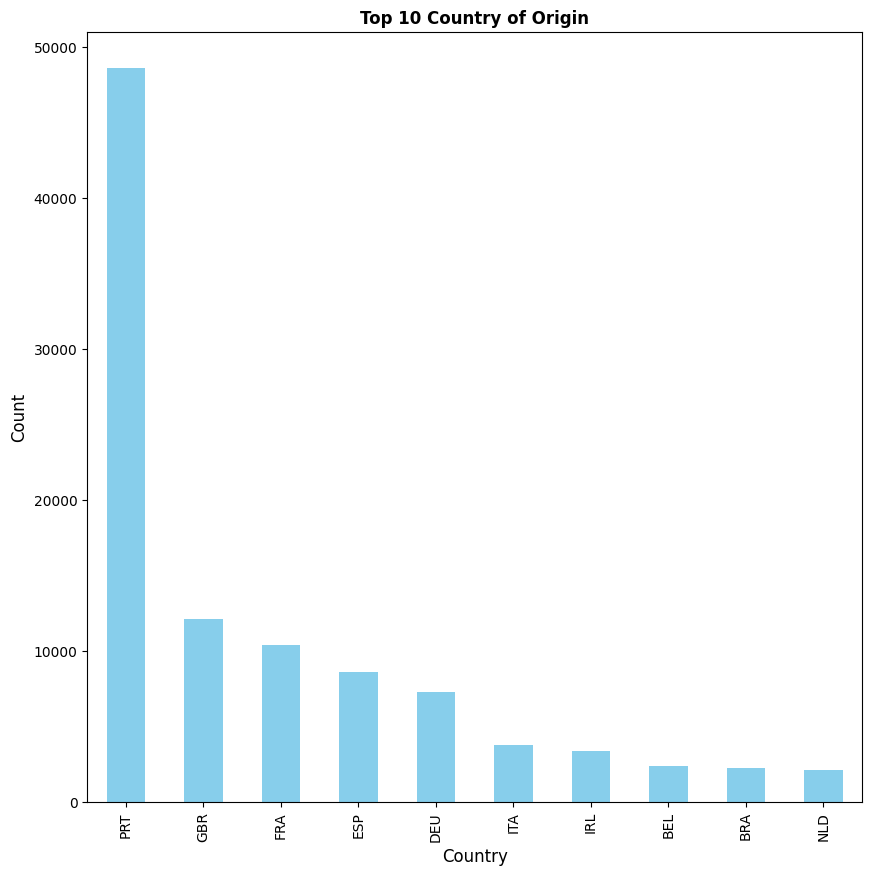

In [19]:
top_10_countries = hotel_df['country'].value_counts().head(10)
top_10_countries.plot(kind='bar', figsize=(10, 10), color='skyblue')
plt.title('Top 10 Country of Origin', weight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)

#ovo san prominila

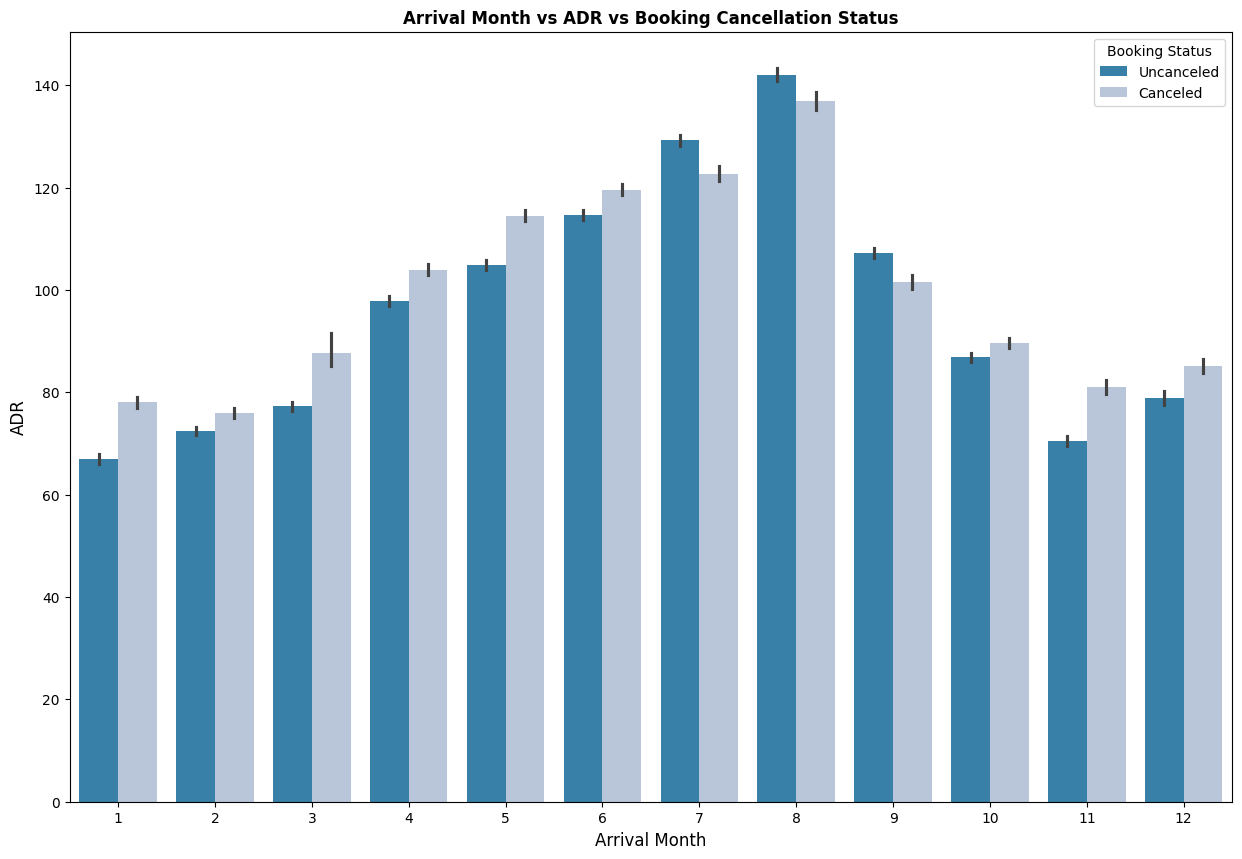

In [20]:
# `Arrival Month` vs `ADR` vs `Booking Cancellation Status`

hotel_df['adr'] = hotel_df['adr'].astype(float)
plt.figure(figsize=(15,10))
sns.barplot(x='arrival_date_month', y='adr', hue='is_canceled', dodge=True, palette= 'PuBu_r', data=hotel_df)
plt.title('Arrival Month vs ADR vs Booking Cancellation Status', weight='bold')
plt.xlabel('Arrival Month', fontsize=12)
plt.ylabel('ADR', fontsize=12)

# Promjena sadržaja legende
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Uncanceled', 'Canceled']  # Novi tekst legende
plt.legend(handles, labels, title="Booking Status")


# Prikazivanje grafa
plt.show()

#ODE SAN MINJALA LEGENDU

Ovaj kod prikazuje bar graf koji istražuje odnos između tri varijable iz skupa podataka: mjesec dolaska (arrival_date_month), prosječna dnevna cijena sobe (adr) i status otkazivanja rezervacije (is_canceled).

DEALING WITH MISSING DATA AND CORRELATION MATRIX

In [21]:
## Display sum of null data

hotel_df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [22]:
# Fill missing data

hotel_df['children'] =  hotel_df['children'].fillna(0)
hotel_df['all_children'] =  hotel_df['all_children'].fillna(0)
hotel_df['country'] = hotel_df['country'].fillna(hotel_df['country'].mode().index[0])
hotel_df['agent']= hotel_df['agent'].fillna('0')
hotel_df=hotel_df.drop(['company'], axis =1)

In [23]:
# Change data type

hotel_df['agent']= hotel_df['agent'].astype(int)
#hotel_df['country']= hotel_df['country'].astype(O)

In [24]:
#Using Label Encoder method for categorical features

cols =  [cols for cols in hotel_df.columns if hotel_df[cols].dtype == 'O']

hotel_df.loc[:, cols] = hotel_df.loc[:, cols].astype(str).apply(LabelEncoder().fit_transform)

In [25]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,weekend_or_weekday,all_children
0,1,0,342,2015,7,27,1,0,0,2,...,0,0,2,0.0,0,0,1,121,3,0.0
1,1,0,737,2015,7,27,1,0,0,2,...,0,0,2,0.0,0,0,1,121,3,0.0
2,1,0,7,2015,7,27,1,0,1,1,...,0,0,2,75.0,0,0,1,122,2,0.0
3,1,0,13,2015,7,27,1,0,1,1,...,304,0,2,75.0,0,0,1,122,2,0.0
4,1,0,14,2015,7,27,1,0,2,2,...,240,0,2,98.0,0,1,1,123,2,0.0


In [26]:
#Create new dataframe for categorical data

hotel_data_categorical = hotel_df[['hotel','is_canceled','arrival_date_month','meal',
                                     'country','market_segment','distribution_channel',
                                     'is_repeated_guest', 'reserved_room_type',
                                     'assigned_room_type','deposit_type','agent',
                                     'customer_type','reservation_status',
                                     'weekend_or_weekday']]
hotel_data_categorical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   hotel                 119390 non-null  object
 1   is_canceled           119390 non-null  int64 
 2   arrival_date_month    119390 non-null  int64 
 3   meal                  119390 non-null  object
 4   country               119390 non-null  object
 5   market_segment        119390 non-null  object
 6   distribution_channel  119390 non-null  object
 7   is_repeated_guest     119390 non-null  int64 
 8   reserved_room_type    119390 non-null  object
 9   assigned_room_type    119390 non-null  object
 10  deposit_type          119390 non-null  object
 11  agent                 119390 non-null  int64 
 12  customer_type         119390 non-null  object
 13  reservation_status    119390 non-null  object
 14  weekend_or_weekday    119390 non-null  object
dtypes: int64(4), obje

In [27]:
#Create new dataframe for numerical data

hotel_data_numerical= hotel_df.drop(['hotel','is_canceled', 'arrival_date_month','meal',
                                       'country','market_segment','distribution_channel',
                                       'is_repeated_guest', 'reserved_room_type',
                                       'assigned_room_type','deposit_type','agent',
                                       'customer_type','reservation_status',
                                       'weekend_or_weekday'], axis = 1)
hotel_data_numerical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   lead_time                       119390 non-null  int64  
 1   arrival_date_year               119390 non-null  int64  
 2   arrival_date_week_number        119390 non-null  int64  
 3   arrival_date_day_of_month       119390 non-null  int64  
 4   stays_in_weekend_nights         119390 non-null  int64  
 5   stays_in_week_nights            119390 non-null  int64  
 6   adults                          119390 non-null  int64  
 7   children                        119390 non-null  float64
 8   babies                          119390 non-null  int64  
 9   previous_cancellations          119390 non-null  int64  
 10  previous_bookings_not_canceled  119390 non-null  int64  
 11  booking_changes                 119390 non-null  int64  
 12  days_in_waiting_

Text(0.5, 1.0, 'Correlation Matrix Spearman Method- Categorical Data ')

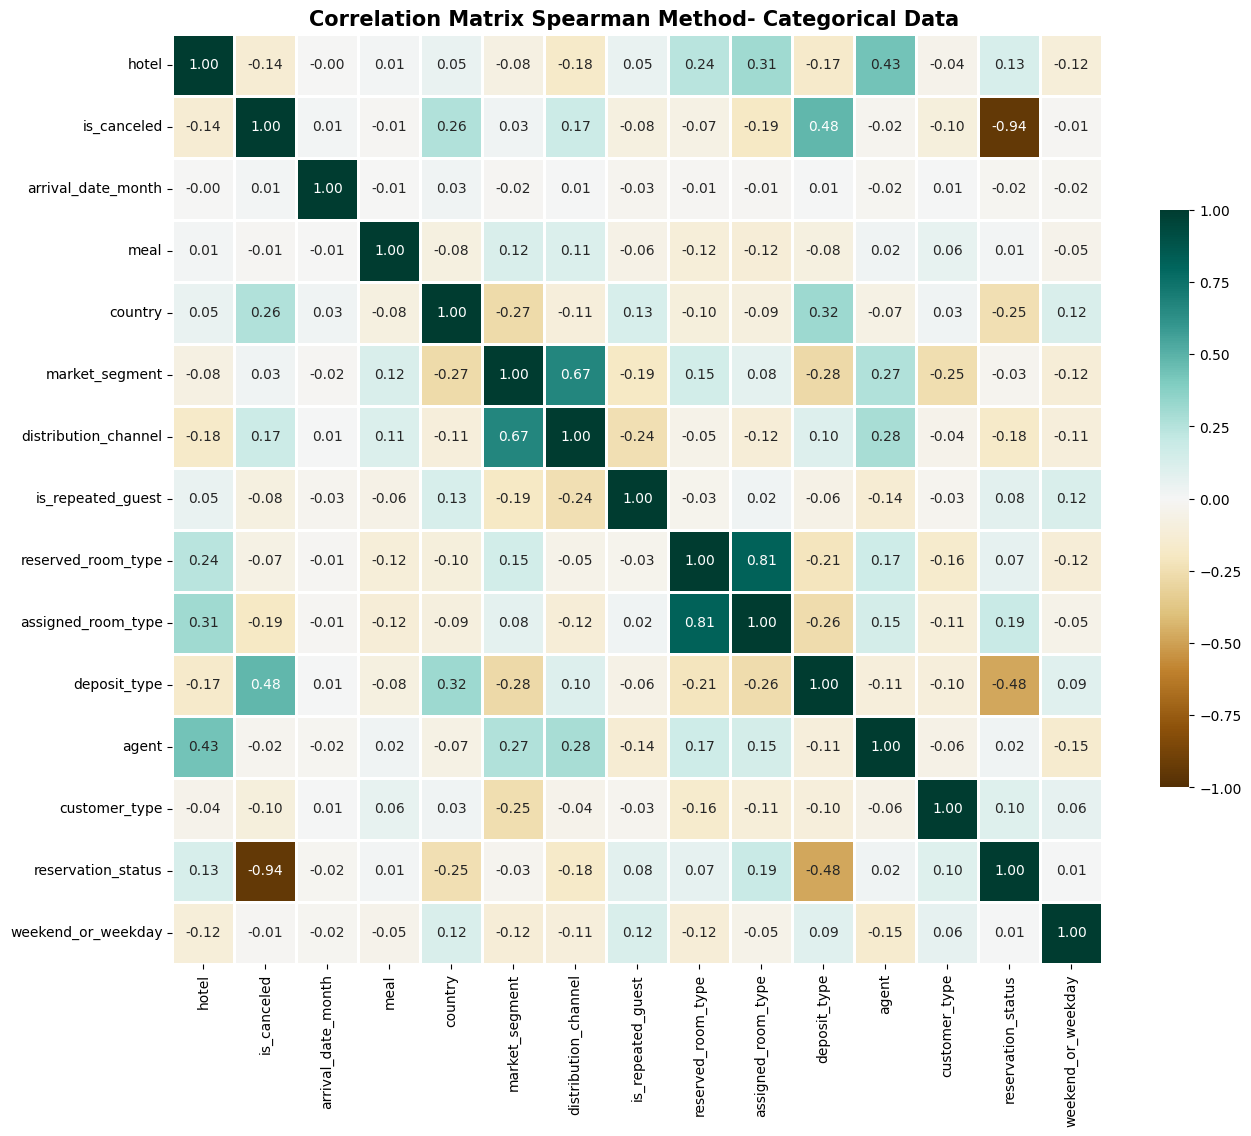

In [28]:
# Correlation Matrix with Spearman method

plt.figure(figsize=(15,15))
corr_categorical=hotel_data_categorical.corr(method='spearman')
mask_categorical = np.triu(np.ones_like(corr_categorical, dtype=bool))

sns.heatmap(corr_categorical, annot=True, fmt=".2f", cmap='BrBG', vmin=-1, vmax=1, center= 0,
            square=True, linewidths=2, cbar_kws={"shrink": .5}).set(ylim=(15, 0))
plt.title("Correlation Matrix Spearman Method- Categorical Data ",size=15, weight='bold')

Text(0.5, 1.0, 'Correlation Matrix Pearson Method- Numerical Data ')

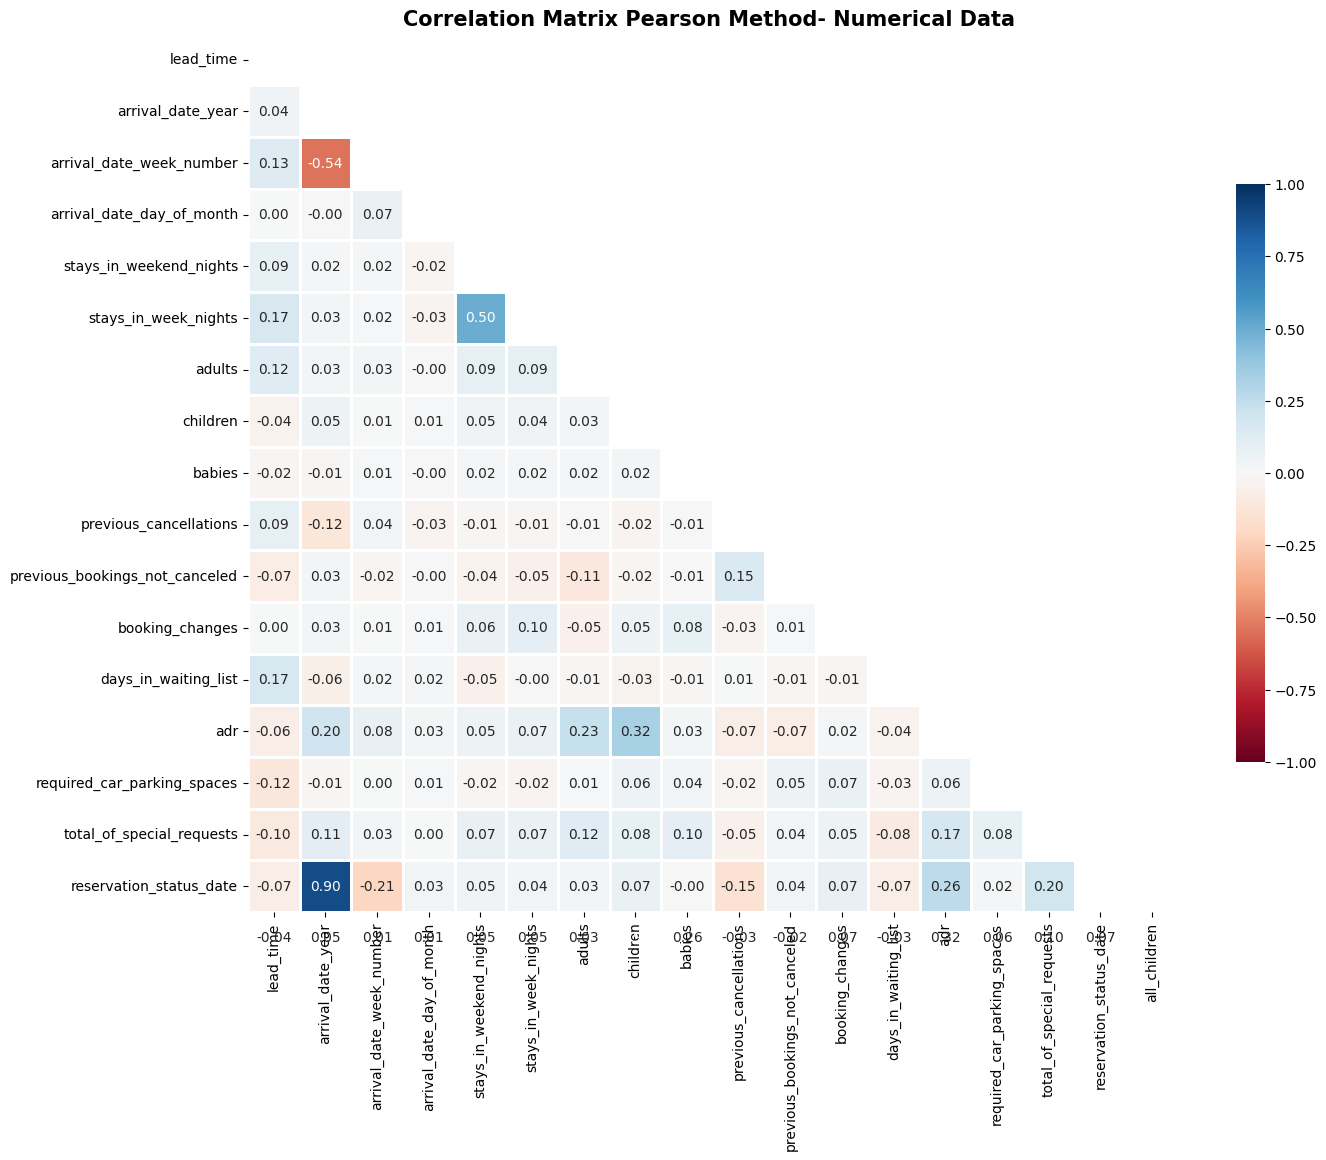

In [29]:
# Correlation Matrix with pearson method

plt.figure(figsize=(15,15))
corr_numerical=hotel_data_numerical.corr(method='pearson')
mask_numerical = np.triu(np.ones_like(corr_numerical, dtype=bool))
sns.heatmap(corr_numerical, annot=True, fmt=".2f", cmap='RdBu', mask= mask_numerical, vmin=-1, vmax=1, center= 0,
            square=True, linewidths=2, cbar_kws={"shrink": .5}).set(ylim=(17, 0))
plt.title("Correlation Matrix Pearson Method- Numerical Data ",size=15, weight='bold')

In [30]:
# Finding high correlated features

corr_mask_categorical = corr_categorical.mask(mask_categorical)
corr_values_categorical = [c for c in corr_mask_categorical.columns if any (corr_mask_categorical[c] > 0.90)]
corr_mask_numerical = corr_numerical.mask(mask_numerical)
corr_values_numerical = [c for c in corr_mask_numerical.columns if any (corr_mask_numerical[c] > 0.90)]
print(corr_values_categorical, corr_values_numerical)

[] ['children']


In [31]:
# drop the highly correlated features

hotel_df = hotel_df.drop(['reservation_status', 'children', 'reservation_status_date'], axis=1)

In [32]:
# Seperate target variable

hotel_data_tunning = hotel_df
y = hotel_data_tunning.iloc[:,1]
x = pd.concat([hotel_data_tunning.iloc[:,0],hotel_data_tunning.iloc[:,2:30]], axis=1)

TEST I TRAIN

In [33]:
# train and test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [34]:
print('X train size: ', x_train.shape)
print('y train size: ', y_train.shape)
print('X test size: ', x_test.shape)
print('y test size: ', y_test.shape)

X train size:  (83573, 29)
y train size:  (83573,)
X test size:  (35817, 29)
y test size:  (35817,)


LOGISTIC REGRESSION

In [35]:
# Create adaboost classifer object
lr = LogisticRegression()

# Train Adaboost Classifer
lr.fit(x_train, y_train)

#Predict the response for test dataset
y_pred = lr.predict(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
precision_score_lr =  precision_score(y_test, y_pred)
accuracy_score_lr = accuracy_score(y_test, y_pred)
print('The precision score is : ',round(precision_score_lr * 100,2), '%')
print('The accuracy score is : ',round(accuracy_score_lr * 100,2), '%')
print ('\nClassification Report TEST:\n', classification_report(y_test,y_pred))

The precision score is :  68.74 %
The accuracy score is :  73.63 %

Classification Report TEST:
               precision    recall  f1-score   support

           0       0.76      0.86      0.80     22478
           1       0.69      0.54      0.60     13339

    accuracy                           0.74     35817
   macro avg       0.72      0.70      0.70     35817
weighted avg       0.73      0.74      0.73     35817



AdaBoost Classifier

In [37]:
import sklearn
print(sklearn.__version__)

1.6.1


In [38]:
# base estimator (optional)
dt = DecisionTreeClassifier()

# Create adaboost classifer object
abc = AdaBoostClassifier(n_estimators=250,learning_rate=1.0, random_state=0)

# Train Adaboost Classifer
abc.fit(x_train, y_train)

#Predict the response for test dataset
y_pred_lg = abc.predict(x_test)

In [39]:
precision_score_ab =  precision_score(y_test, y_pred_lg)
accuracy_score_ab = accuracy_score(y_test, y_pred_lg)
print('The precision score is : ',round(precision_score_ab * 100,2), '%')
print('The accuracy score is : ',round(accuracy_score_ab * 100,2), '%')
print ('\nClassification Report TEST:\n', classification_report(y_test,y_pred_lg))

The precision score is :  83.16 %
The accuracy score is :  82.81 %

Classification Report TEST:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87     22478
           1       0.83      0.68      0.75     13339

    accuracy                           0.83     35817
   macro avg       0.83      0.80      0.81     35817
weighted avg       0.83      0.83      0.82     35817



GRADIENT BOOSTING CLASSIFIER

In [40]:
# create object
gbc= GradientBoostingClassifier(learning_rate=0.1,min_samples_leaf=10, min_samples_split=200, max_features='sqrt',random_state=10)

# Train Adaboost Classifer
gbc.fit(x_train, y_train)

#Predict the response for test dataset
y_pred_gbc = gbc.predict(x_test)

In [41]:
precision_score_gbc =  precision_score(y_test, y_pred_gbc)
accuracy_score_gbc = accuracy_score(y_test, y_pred_gbc)
print('The precision score  is : ',round(precision_score_gbc * 100,2), '%')
print('The accuracy score  is : ',round(accuracy_score_gbc * 100,2), '%')
print ('\nClassification Report TEST:\n', classification_report(y_test,y_pred_gbc))

The precision score  is :  85.75 %
The accuracy score  is :  84.55 %

Classification Report TEST:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88     22478
           1       0.86      0.70      0.77     13339

    accuracy                           0.85     35817
   macro avg       0.85      0.82      0.83     35817
weighted avg       0.85      0.85      0.84     35817



XGBoost

In [46]:
xgbc = XGBClassifier(max_depth=13,n_estimators=300,learning_rate=0.5, enable_categorical=True)

# Pretvori kategorijske stupce u 'category' tip
for col in x_train.select_dtypes(include=['object']).columns:
    x_train[col] = x_train[col].astype('category')
    x_test[col] = x_test[col].astype('category')


# Train Adaboost Classifer
xgbc.fit(x_train, y_train)

#Predict the response for test dataset
y_pred_xgbc = xgbc.predict(x_test)

In [43]:
import xgboost
print(xgboost.__version__)

print(x_train.dtypes)  #  tipov svih kolona


2.1.3
hotel                             category
lead_time                            int64
arrival_date_year                    int64
arrival_date_month                   int64
arrival_date_week_number             int64
arrival_date_day_of_month            int64
stays_in_weekend_nights              int64
stays_in_week_nights                 int64
adults                               int64
babies                               int64
meal                              category
country                           category
market_segment                    category
distribution_channel              category
is_repeated_guest                    int64
previous_cancellations               int64
previous_bookings_not_canceled       int64
reserved_room_type                category
assigned_room_type                category
booking_changes                      int64
deposit_type                      category
agent                                int64
days_in_waiting_list                 int64
custo

In [48]:
precision_score_xgbc =  precision_score(y_test, y_pred_xgbc)
accuracy_score_xgbc = accuracy_score(y_test, y_pred_xgbc)
print('The precision score  is : ',round(precision_score_xgbc * 100,2), '%')
print('The accuracy score is : ',round(accuracy_score_xgbc * 100,2), '%')
print ('\nClassification Report TEST:\n', classification_report(y_test,y_pred_xgbc))

The precision score  is :  84.81 %
The accuracy score is :  82.02 %

Classification Report TEST:
               precision    recall  f1-score   support

           0       0.81      0.93      0.87     22478
           1       0.85      0.63      0.72     13339

    accuracy                           0.82     35817
   macro avg       0.83      0.78      0.79     35817
weighted avg       0.82      0.82      0.81     35817



PREGLED

In [49]:
print('Logistic Regression accuracy score is : ',round(accuracy_score_lr * 100,2), '%')
print('AdaBoost accuracy score is : ',round(accuracy_score_ab * 100,2), '%')
print('Gradient boosting  accuracy score  is : ',round(accuracy_score_gbc * 100,2), '%')
print('XGBoost accuracy score is : ',round(accuracy_score_xgbc * 100,2), '%')

Logistic Regression accuracy score is :  73.63 %
AdaBoost accuracy score is :  82.81 %
Gradient boosting  accuracy score  is :  84.55 %
XGBoost accuracy score is :  82.02 %
